# Lab 4: MNIST-MLP
---

Grupo 3 \
Alexandre Rodrigues: 75545 \
Tiago Granja: 79845 \
Diogo Silva: 79828

Import libraries

In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sn

## Three or not a three

The MNIST dataset (Modified National Institute of Standards and Technology) is a classic dataset in machine learning and computer vision, often remarked as the "Hello World" of machine learning. This dataset contains handwritten digits, each one being a 28x28 grayscale image. In this assignment we will work with a variation of the MNIST where each digit is a 20x20 grayscale image, rather than a 28x28, and we are only concerned in distinguishing the digit "3" from all other digits with the use of MLP's (Multi-Layer Perceptron).

## Extracting data

The given dataset contains 5000 samples, each sample being a 20x20 grayscale image of a digit, with 500 of each digit making it a balanced dataset.

In [2]:
def print_dataset(x: np.ndarray, y: np.ndarray) -> None:
    print(f"X {x.shape}:")
    print(x)
    print(f"\nY {y.shape}:")
    print(y)

In [3]:
raw = scipy.io.loadmat('digits.mat')
x = raw['X']

# Train dataset is rotated when compared to kaggle dataset
x = np.reshape(x, (-1, 20, 20), order="F")
x = np.reshape(x, (-1, 400))

y = raw['y']
print_dataset(x, y)

X (5000, 400):
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

Y (5000, 1):
[[10]
 [10]
 [10]
 ...
 [ 9]
 [ 9]
 [ 9]]


In [4]:
def print_class_frequency(y: np.ndarray) -> None:
    unique, count = np.unique(y, return_counts=True)
    print(unique)
    print(count)

print_class_frequency(y)

[ 1  2  3  4  5  6  7  8  9 10]
[500 500 500 500 500 500 500 500 500 500]


However, since we are only interested in distinguishing the digit "3" from other digits, we have 4500 samples of "not three" digits and 500 samples of the digit 3, creating a class imbalance between the positive and negative class of 1 to 9.

In [5]:
y = np.where(y == 3, 1, 0)
print_dataset(x, y)

X (5000, 400):
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

Y (5000, 1):
[[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]


In [6]:
print_class_frequency(y)

[0 1]
[4500  500]


We then shuffle our dataset and split it into a training set and a validation set, with 80% for training and 20% for validation/testing.

In [7]:
permutation = np.random.permutation(x.shape[0])
x = x[permutation]
y = y[permutation]

In [8]:
training_percentage = 0.8
training_size = int(x.shape[0] * training_percentage)

x_train = x[:training_size]
x_test = x[training_size:]
y_train = y[:training_size]
y_test = y[training_size:]

print(f"Training size = {x_train.shape[0]}")
print(f"Testing size = {x_test.shape[0]}")

Training size = 4000
Testing size = 1000


In [9]:
print_class_frequency(y_train)

[0 1]
[3610  390]


## Data augmentation

Data augmentation is a crucial step before training our network. By artificially increasing the size of our training dataset with new augmented samples, we are able to train denser and deeper networks. We generate these new samples by applying geometrical transformations, like slight rotations to represent tilted digits or zooming in and out to represent different shapes and sizes of the same digit. We also apply a noisy filter to our samples to further increase our dataset size. To combat the class imbalance of the problem, we used SMOTE (Synthetic Minority Over-sampling Technique) to oversample the minority class and have a better balanced dataset, before any data augmentation.

In [10]:
def display_sample(x: np.ndarray, height: int, width: int) -> None:
        img = np.reshape(x, (height, width))
        h = plt.imshow(img)
        plt.axis('off')
        plt.gray()
        plt.show()

### SMOTE

SMOTE was used to generate samples for the minority class. SMOTE works by interpolating new samples from the minority class using $k$ neighbors.

In [11]:
sm = SMOTE(sampling_strategy=1)
x_train, y_train = sm.fit_resample(x_train, y_train)
y_train = np.reshape(y_train, (-1, 1))

print_class_frequency(y_train)

[0 1]
[3610 3610]


In [12]:
x_train_20x20 = np.reshape(x_train, (-1, 20, 20, 1))

### Zooming in and out

We applied a random zoom to all samples, by either zooming in by a random factor, between 10% to 20% in both axis, or zooming out a random factor within the same boundary.

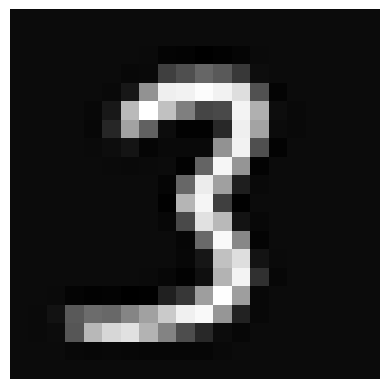

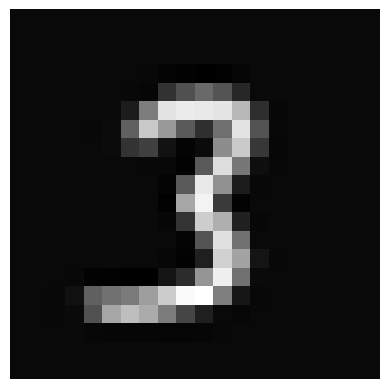

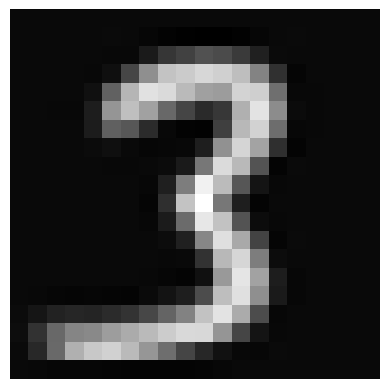

In [13]:
zoom_out_layer = layers.RandomZoom(height_factor=(0.1, 0.2), width_factor=(0.1, 0.2), fill_mode="constant", fill_value=0)
zoom_in_layer = layers.RandomZoom(height_factor=(-0.2, -0.1), width_factor=(-0.2, -0.1), fill_mode="constant", fill_value=0)
x_train_zoom_out_20x20 = zoom_out_layer(x_train_20x20)
x_train_zoom_in_20x20 = zoom_in_layer(x_train_20x20)
x_train_zoom_out = np.reshape(x_train_zoom_out_20x20, (-1, 400))
x_train_zoom_in = np.reshape(x_train_zoom_in_20x20, (-1, 400))

display_sample(x_train[67], 20, 20)
display_sample(x_train_zoom_out[67], 20, 20)
display_sample(x_train_zoom_in[67], 20, 20)

### Rotating left and right

We applied a random rotation to both direction, by a random factor between 15º to 30º.

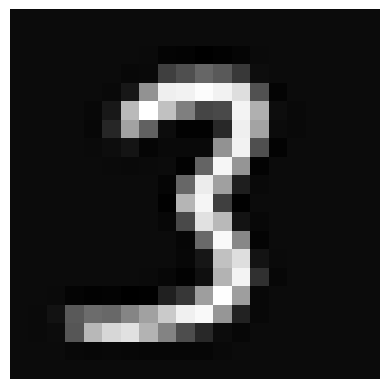

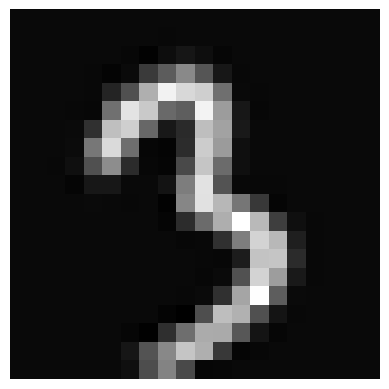

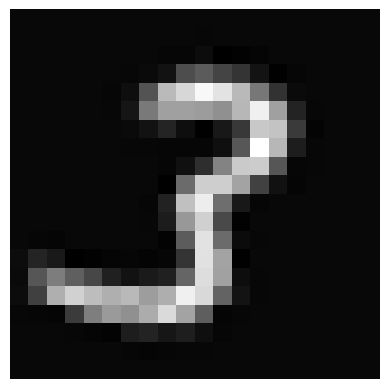

In [14]:
positive_rotation_layer = layers.RandomRotation(factor=(1/24, 1/12), fill_mode="constant", fill_value=0)
negative_rotation_layer = layers.RandomRotation(factor=(-1/12, -1/24), fill_mode="constant", fill_value=0)
x_train_positive_rotation_20x20 = positive_rotation_layer(x_train_20x20)
x_train_negative_rotation_20x20 = negative_rotation_layer(x_train_20x20)
x_train_positive_rotation = np.reshape(x_train_positive_rotation_20x20, (-1, 400))
x_train_negative_rotation = np.reshape(x_train_negative_rotation_20x20, (-1, 400))

display_sample(x_train[67], 20, 20)
display_sample(x_train_positive_rotation[67], 20, 20)
display_sample(x_train_negative_rotation[67], 20, 20)

In [15]:
x_train = np.concatenate((x_train, x_train_zoom_in))
x_train = np.concatenate((x_train, x_train_zoom_out))
x_train = np.concatenate((x_train, x_train_positive_rotation))
x_train = np.concatenate((x_train, x_train_negative_rotation))

y_train_copy = np.copy(y_train)
y_train = np.concatenate((y_train, y_train_copy))
y_train = np.concatenate((y_train, y_train_copy))
y_train = np.concatenate((y_train, y_train_copy))
y_train = np.concatenate((y_train, y_train_copy))

print_class_frequency(y_train)

[0 1]
[18050 18050]


### Gaussian noise

After all geometric transformations, we apply a Gaussian noise filter to all original and generated samples.

In [16]:
def apply_noise(x: np.ndarray, mean: float, std: float) -> np.ndarray:
    return x + np.random.normal(mean, std, x.shape)

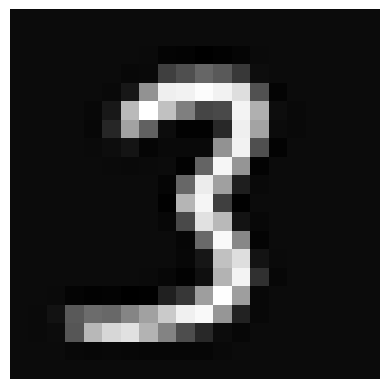

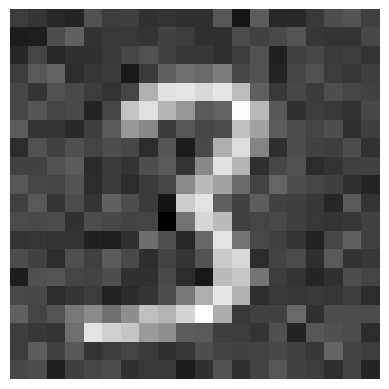

In [17]:
x_train_noisy = apply_noise(x_train, 0.0, 0.1)

display_sample(x_train[67], 20, 20)
display_sample(x_train_noisy[67], 20, 20)

In [18]:
x_train = np.concatenate((x_train, x_train_noisy))

y_train_copy = np.copy(y_train)
y_train = np.concatenate((y_train, y_train_copy))

print_class_frequency(y_train)

[0 1]
[36100 36100]


After all augmentation steps have been done we once again shuffle our training dataset before moving on to training.

In [19]:
permutation = np.random.permutation(x_train.shape[0])
x_train = x_train[permutation]
y_train = y_train[permutation]

## Model architecture and training

With all our data, it's time we design and train our network. We have settled for a moderate 2 hidden dense layer architecture with one output neuron with the following topology 128\:64\:1. Hidden layers use ReLu activation functions while the output neuron uses a sigmoid activation for interpretability. We apply a L2 regularization to both hidden layers, with a greater intensity to the first layer when compared to the second layer. For training, we used the binary cross entropy loss function as it is suited for binary classification problems. For our optimizer we use the ADAM optimizer with a learning rate of $0.0001$.

In [20]:
l2_reg = 0.002
model = keras.Sequential([
    layers.Input(shape=(x.shape[1],)),
    layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(l2_reg)),
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(l2_reg / 2)),
    layers.Dense(1, activation='sigmoid')
])

model.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy", "precision", "recall", tf.keras.metrics.F1Score(threshold=0.5)])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        51,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,649 (233.00 KB)

 Trainable params: 59,649 (233.00 KB)

 Non-trainable params: 0 (0.00 B)

For training, we use a batch size of 256, and we do, at most, 1000 epochs. However, we employ early stop with a patience value of 10 if no good enough improvement is found. During training, we monitor the loss but also accuracy, precision, recall and F1 score.

In [21]:
batch_size = 256
epochs = 1000
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, min_delta=10e-6, restore_best_weights=True, start_from_epoch=10)

training_history=model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, shuffle=True, 
                           callbacks=[early_stop], validation_data=(x_test, y_test), verbose=0)

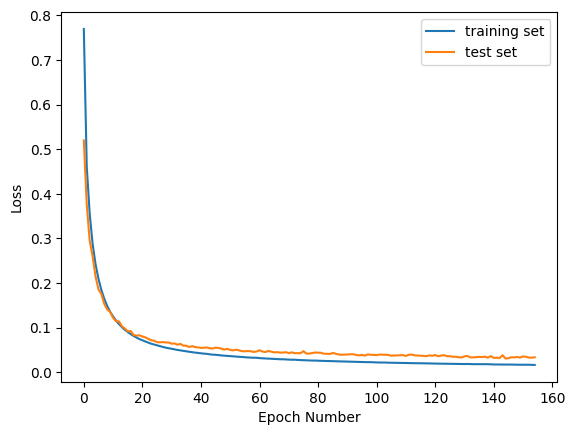

In [22]:
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.plot(training_history.history['loss'], label='training set')
plt.plot(training_history.history['val_loss'], label='test set')
plt.legend()

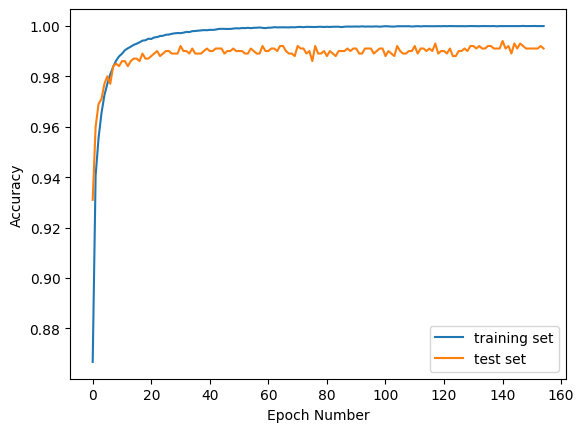

In [23]:
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.plot(training_history.history['accuracy'], label='training set')
plt.plot(training_history.history['val_accuracy'], label='test set')
plt.legend()

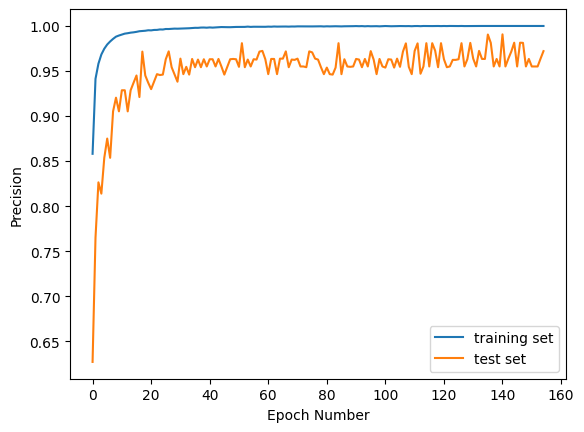

In [24]:
plt.xlabel('Epoch Number')
plt.ylabel('Precision')
plt.plot(training_history.history['precision'], label='training set')
plt.plot(training_history.history['val_precision'], label='test set')
plt.legend()

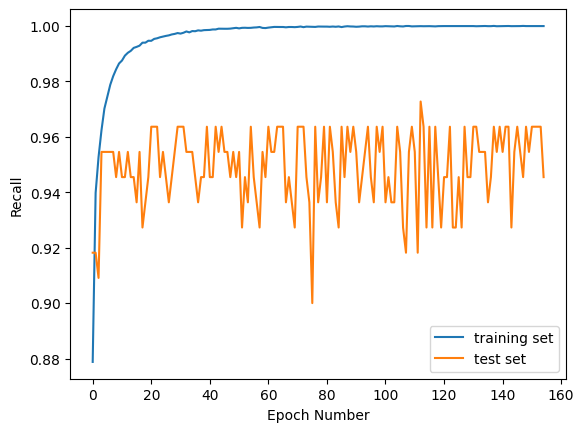

In [25]:
plt.xlabel('Epoch Number')
plt.ylabel('Recall')
plt.plot(training_history.history['recall'], label='training set')
plt.plot(training_history.history['val_recall'], label='test set')
plt.legend()

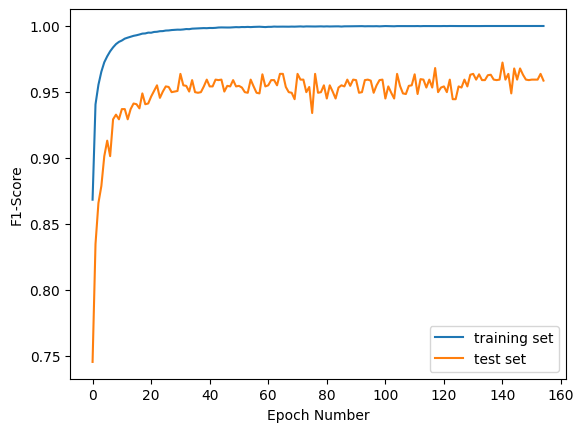

In [26]:
plt.xlabel('Epoch Number')
plt.ylabel('F1-Score')
plt.plot(training_history.history['f1_score'], label='training set')
plt.plot(training_history.history['val_f1_score'], label='test set')
plt.legend()

## Model evaluation

In [27]:
score = model.evaluate(x_train, y_train)
print("Train loss:", score[0])
print("Train accuracy:", score[1])
print("Train precision:", score[2])
print("Train recall:", score[3])
print("Train f1-score:", score[4])

2257/2257 ━━━━━━━━━━━━━━━━━━━━ 1s 308us/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0172 - precision: 1.0000 - recall: 1.0000
Train loss: 0.017200162634253502
Train accuracy: 0.9999722838401794
Train precision: 0.9999722838401794
Train recall: 0.9999722838401794
Train f1-score: [0.9999722]


In [28]:
score = model.evaluate(x_test, y_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])
print("Test precision:", score[2])
print("Test recall:", score[3])
print("Test f1-score:", score[4])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - accuracy: 0.9930 - f1_score: 0.9677 - loss: 0.0311 - precision: 0.9813 - recall: 0.9545
Test loss: 0.031082531437277794
Test accuracy: 0.9929999709129333
Test precision: 0.9813084006309509
Test recall: 0.9545454382896423
Test f1-score: [0.96774185]


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step


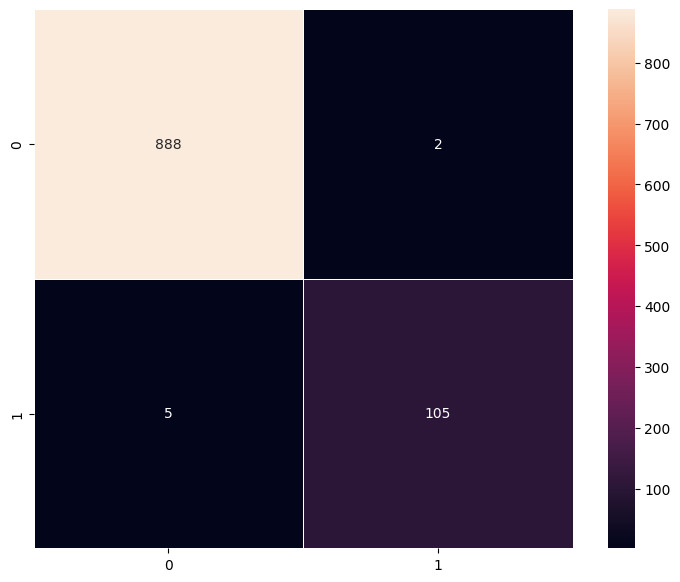

In [29]:
confusion_matrix = tf.math.confusion_matrix(y_test.T[0], np.round(model.predict(x_test).T[0]))
f, ax = plt.subplots(figsize=(9, 7))
sn.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.5,
    fmt="d",
    square=True,
    ax=ax
)
plt.show()

## Kaggle submission

In [30]:
x_eval = np.load("evalX.npy")
y_predicted = np.round(model.predict(x_eval)).astype(int)

out_file = open("predictions.csv", 'w')

out_file.write('id,label\n')
for i in range(y_predicted.shape[0]):
    out_file.write(f'{i},{y_predicted[i][0]}\n')
out_file.close()   

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 201us/step


## Conclusions

Our results show that our model reached a reasonable performance, averaging a F1 score of around 0.96 to 0.97. Despite balancing the dataset, our training results still showed a bias towards wrongly classifying '3', with recall generally being lower than precision. This could mean that better data augmentation methods could have been employed.